# IBS Country ETF — replicating the Min-Max mean-reversion strategy

**Paper:** Pandey & Joshi (2023), *Using Internal Bar Strength as a Key Indicator for
Trading Country ETFs*, arXiv:2306.12434. Local copy: `papers/ibs_strat.pdf`.

**Spec and data requirements:** [`ibs_country_etf.md`](ibs_country_etf.md) — read first.

The rule is one line: **each day, long the country ETF with the lowest IBS and short the
one with the highest, held exactly one session.** IBS locates the close inside the day's
range, so this is a bet that a close on the lows bounces and a close on the highs fades.

The paper reports **Sharpe 2.908** on all 15 ETFs over 2009–2019.

### Why this notebook has three windows instead of one

Alpaca equity history starts **2016-01-04**, so 7 of the paper's 11 years are
unavailable — including 2009–2012, when post-crisis mean reversion was unusually strong.
That is a real limit, but it also creates an opportunity the paper could not have:

| Window | Sessions | What it tests |
|---|---|---|
| 2016-01-04 → 2019-12-31 | 1,005 | the slice of the paper's period we can see |
| 2020-01-01 → 2026-09-08 | 1,678 | out-of-sample |
| **2023-06-14 → 2026-09-08** | 810 | **post-publication** |

A simple, public, high-Sharpe strategy is exactly what should be checked for decay after
it is published. That check is the most useful thing this notebook does.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
while not (ROOT / "backtest").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
HERE = ROOT / "research" / "ibs_country_etf"
OUT = ROOT / "out" / "ibs_country_etf"
sys.path[:0] = [str(HERE), str(ROOT)]

from ibs import UNIVERSE, IBSConfig, compute_ibs, hit_probabilities, run
import metrics as M

pd.set_option("display.width", 180, "display.max_columns", 40)

WINDOWS = ["overlap 2016-2019", "out-of-sample 2020-2026",
           "post-publication 2023-06+", "full 2016-2026"]
SHORT = {"overlap 2016-2019": "2016-19\n(paper window)",
         "out-of-sample 2020-2026": "2020-26\n(out of sample)",
         "post-publication 2023-06+": "2023-26\n(post-publication)",
         "full 2016-2026": "2016-26\n(full)"}
print("artefacts:", "present" if OUT.exists() else "MISSING — run run_backtest.py")

artefacts: present


In [2]:
SERIES = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
          "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948"}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0,
})

## 1 — The mechanism first (paper Table 3)

The paper's causal claim is a conditional probability: after a low-IBS close the next day
tends to be up, and after a high-IBS close it tends to be down. It needs only daily bars,
and if it fails the Sharpe is not worth computing.

The paper's own numbers already contain a warning that its text does not dwell on: the
long column runs 0.54–0.61, while the short column runs 0.46–0.58 and sits **below 0.50**
for IVV, EZU and EWZ. Watch what happens to each leg separately.

,long: P(up | IBS<0.2),short: P(down | IBS>0.8)
window,,
overlap 2016-2019,0.559,0.470
out-of-sample 2020-2026,0.560,0.485
post-publication 2023-06+,0.565,0.460
full 2016-2026,0.559,0.479
PAPER (2009-2019),0.565,0.510


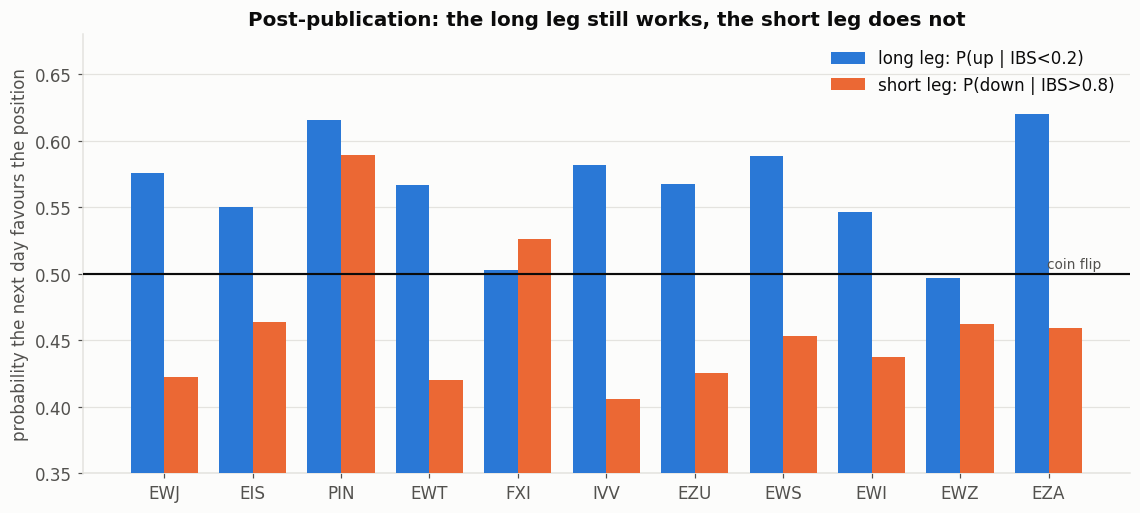

In [3]:
probs = pd.read_parquet(OUT / "hit_probabilities.parquet")
PAPER_P = {"EWJ": (.606, .514), "EIS": (.588, .514), "PIN": (.581, .578),
           "EWT": (.572, .503), "FXI": (.568, .523), "IVV": (.566, .460),
           "EZU": (.552, .477), "EWS": (.550, .515), "EWI": (.548, .511),
           "EWZ": (.544, .508), "EZA": (.541, .510)}
tick = list(PAPER_P)

rows = []
for w in WINDOWS:
    p = probs[probs.window == w].set_index("ticker")
    sub = p.loc[[t for t in tick if t in p.index]]
    rows.append({"window": w,
                 "long: P(up | IBS<0.2)": sub.long_on_ibs_below.mean(),
                 "short: P(down | IBS>0.8)": sub.short_on_ibs_above.mean()})
rows.append({"window": "PAPER (2009-2019)",
             "long: P(up | IBS<0.2)": np.mean([v[0] for v in PAPER_P.values()]),
             "short: P(down | IBS>0.8)": np.mean([v[1] for v in PAPER_P.values()])})
mech = pd.DataFrame(rows).set_index("window")
display(mech.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=.45, vmax=.60))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(tick)); wdt = 0.38
pw = "post-publication 2023-06+"
pp = probs[probs.window == pw].set_index("ticker").loc[tick]
ax.bar(x - wdt/2, pp.long_on_ibs_below, wdt, color=SERIES["blue"], label="long leg: P(up | IBS<0.2)", zorder=3)
ax.bar(x + wdt/2, pp.short_on_ibs_above, wdt, color=SERIES["orange"], label="short leg: P(down | IBS>0.8)", zorder=3)
ax.axhline(0.5, color=INK, lw=1.4, zorder=4)
ax.annotate("coin flip", xy=(len(tick)-0.4, 0.502), fontsize=9, color=INK_2, va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels(tick)
ax.set_ylim(0.35, 0.68); ax.set_ylabel("probability the next day favours the position")
ax.set_title("Post-publication: the long leg still works, the short leg does not")
ax.legend(loc="upper right"); ax.xaxis.grid(False); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**This is the finding.** The long leg replicates almost exactly and *persists* — 0.559,
0.560, 0.565 across the three windows against the paper's 0.565. The short leg does not:
0.470, 0.485, 0.460 against the paper's 0.510, and **below 0.50 in every window**.

Below 0.50 means shorting high-IBS country ETFs is a losing bet. That is not mysterious —
equity ETFs have positive drift, and shorting into it needs a mean-reversion edge large
enough to overcome the drift. The paper's own 0.510 was already marginal.

Prediction to carry forward: **long-only should beat long/short**, and increasingly so in
later windows.

## 2 — Headline (paper Table 2: Sharpe 2.908)

,MinMax Sharpe,IVV buy&hold Sharpe,MinMax CAGR,MinMax vol,MinMax MDD
window,,,,,
overlap 2016-2019,1.70,1.14,18.2%,10.1%,11.4%
out-of-sample 2020-2026,0.97,0.81,11.4%,11.8%,26.4%
post-publication 2023-06+,0.67,1.35,7.2%,11.4%,20.8%
full 2016-2026,1.22,0.89,13.9%,11.2%,26.4%


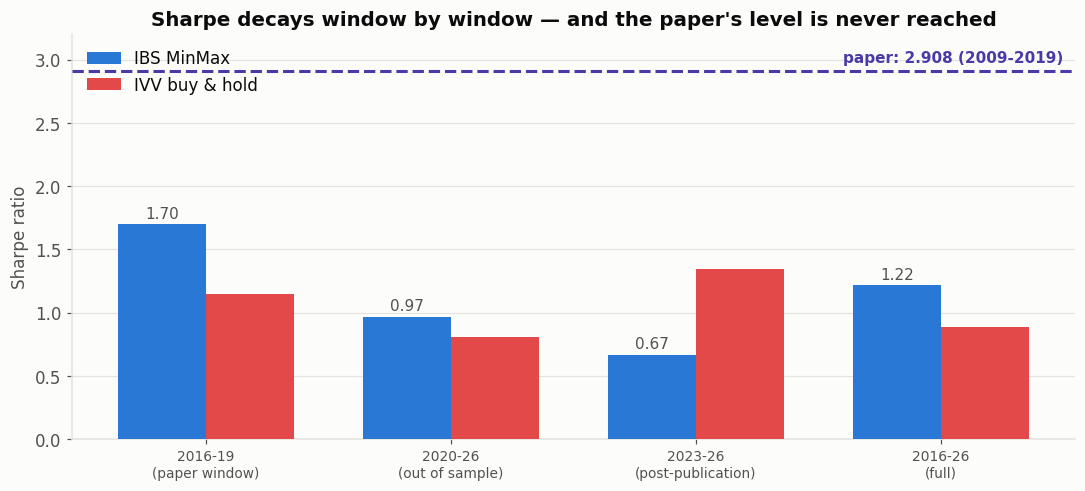

In [4]:
head = pd.read_parquet(OUT / "headline.parquet")
mm = head[head.strategy.str.startswith("MinMax")].set_index("window")
bh = head[head.strategy.str.startswith("IVV")].set_index("window")

cmp = pd.DataFrame({
    "MinMax Sharpe": mm.sharpe, "IVV buy&hold Sharpe": bh.sharpe,
    "MinMax CAGR": mm.cagr, "MinMax vol": mm.volatility, "MinMax MDD": mm.mdd,
}).loc[WINDOWS]
display(cmp.style.format({"MinMax Sharpe": "{:.2f}", "IVV buy&hold Sharpe": "{:.2f}",
                          "MinMax CAGR": "{:.1%}", "MinMax vol": "{:.1%}",
                          "MinMax MDD": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(WINDOWS)); wdt = 0.36
ax.bar(x - wdt/2, mm.loc[WINDOWS].sharpe, wdt, color=SERIES["blue"], label="IBS MinMax", zorder=3)
ax.bar(x + wdt/2, bh.loc[WINDOWS].sharpe, wdt, color=SERIES["red"], label="IVV buy & hold", zorder=3)
ax.axhline(2.908, color=SERIES["violet"], lw=2, ls="--", zorder=4)
ax.annotate("paper: 2.908 (2009-2019)", xy=(len(WINDOWS)-0.5, 2.908), xytext=(0, 6),
            textcoords="offset points", ha="right", color=SERIES["violet"],
            fontsize=10, fontweight="bold")
for xi, v in enumerate(mm.loc[WINDOWS].sharpe):
    ax.annotate(f"{v:.2f}", (xi - wdt/2, v), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=10, color=INK_2)
ax.set_xticks(x); ax.set_xticklabels([SHORT[w] for w in WINDOWS], fontsize=9)
ax.set_ylabel("Sharpe ratio"); ax.set_ylim(0, 3.2)
ax.set_title("Sharpe decays window by window — and the paper's level is never reached")
ax.legend(loc="upper left"); ax.xaxis.grid(False); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

The strategy is **real but far weaker than advertised**, and it is fading:

- **1.70** on the slice of the paper's own window we can see — against 2.908.
- **0.97** out-of-sample.
- **0.67** post-publication, at which point it is beaten by simply holding IVV (1.35).

Part of the 2.908 → 1.70 gap is the missing 2009–2015 data, which contained the
strongest mean-reversion regime in modern equity history. But the monotone slide across
2016-19 → 2020-26 → 2023-26 cannot be explained by the missing years, because those
windows all use the same data source and the same code.

## 3 — Long leg vs short leg

leg,long only,short only,long+short
window,,,
overlap 2016-2019,1.40,0.28,1.70
out-of-sample 2020-2026,0.93,-0.06,0.97
post-publication 2023-06+,1.15,-0.43,0.67
full 2016-2026,1.08,0.04,1.22


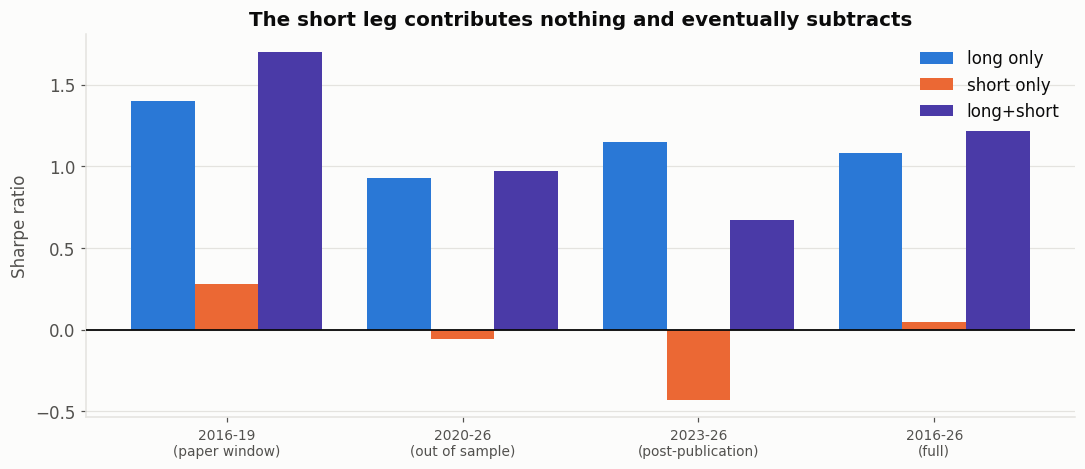

In [5]:
legs = pd.read_parquet(OUT / "legs.parquet")
piv = legs.pivot(index="window", columns="leg", values="sharpe").loc[WINDOWS]
display(piv[["long only", "short only", "long+short"]].style.format("{:.2f}"))

fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(len(WINDOWS)); wdt = 0.27
for i, (leg, col) in enumerate([("long only", "blue"), ("short only", "orange"),
                                ("long+short", "violet")]):
    ax.bar(x + (i-1)*wdt, piv[leg], wdt, color=SERIES[col], label=leg, zorder=3)
ax.axhline(0, color=INK, lw=1.2, zorder=4)
ax.set_xticks(x); ax.set_xticklabels([SHORT[w] for w in WINDOWS], fontsize=9)
ax.set_ylabel("Sharpe ratio")
ax.set_title("The short leg contributes nothing and eventually subtracts")
ax.legend(loc="upper right"); ax.xaxis.grid(False); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Exactly as the mechanism predicted. Short-only goes **0.28 → −0.06 → −0.43**. By the
post-publication window, long-only (**1.15**) beats the full long/short strategy
(**0.67**) — the short leg is actively destroying value.

The paper noticed the direction of this (Table 4 shows long-only Sharpes above short-only)
but framed it as a mild preference. On this data it is the difference between a strategy
that still works and one that does not.

## 4 — Equity curves

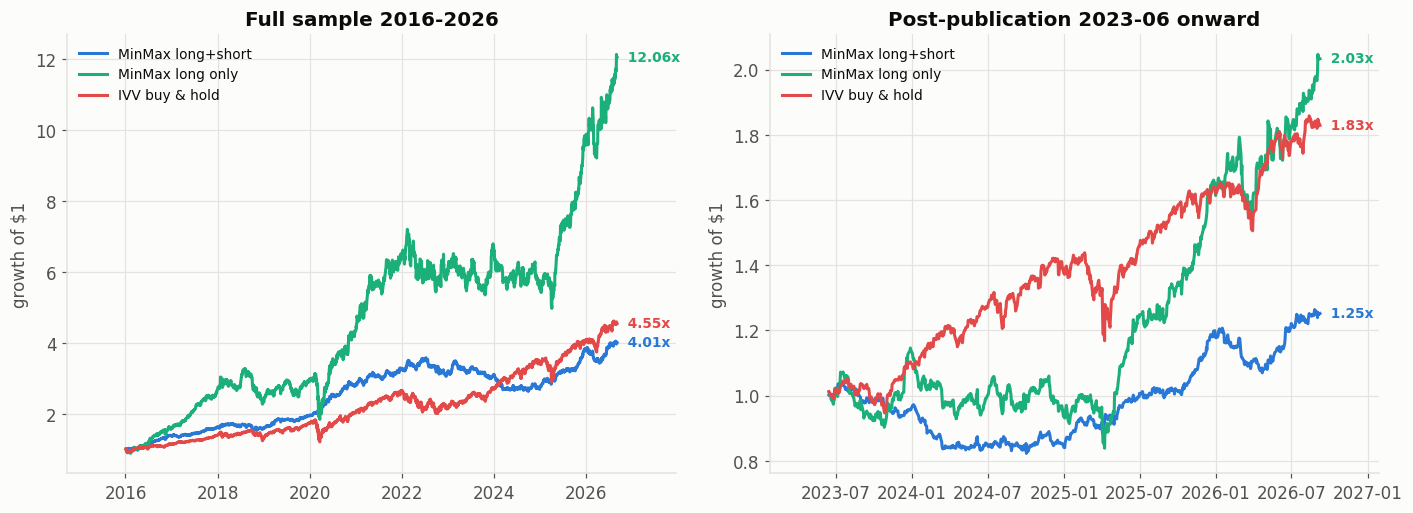

In [6]:
eq = pd.read_parquet(OUT / "equity_curves.parquet")
eq.index = pd.to_datetime(eq.index)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, win, title in [(axes[0], "full 2016-2026", "Full sample 2016-2026"),
                       (axes[1], "post-publication 2023-06+", "Post-publication 2023-06 onward")]:
    for lbl, col in [("MinMax long+short", "blue"), ("MinMax long only", "aqua"),
                     ("IVV buy & hold", "red")]:
        key = f"{lbl} | {win}"
        if key in eq.columns:
            s = eq[key].dropna()
            ax.plot(s.index, s, color=SERIES[col], label=lbl, zorder=3)
            ax.annotate(f" {s.iloc[-1]:.2f}x", xy=(s.index[-1], s.iloc[-1]),
                        xytext=(4, 0), textcoords="offset points",
                        color=SERIES[col], fontsize=9, fontweight="bold", va="center")
    ax.set_title(title); ax.set_ylabel("growth of $1"); ax.margins(x=0.12)
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 5 — The paper's variant claims, checked one by one

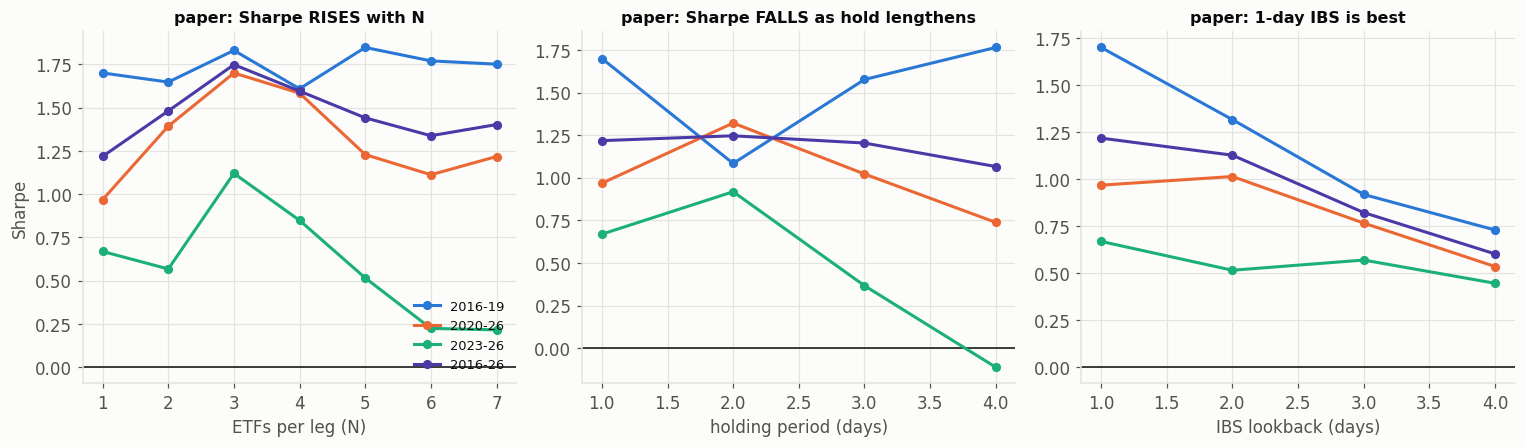


n_positions:
window  overlap 2016-2019  out-of-sample 2020-2026  post-publication 2023-06+  full 2016-2026
value                                                                                        
1                    1.70                     0.97                       0.67            1.22
2                    1.65                     1.39                       0.57            1.48
3                    1.83                     1.70                       1.12            1.75
4                    1.61                     1.58                       0.85            1.60
5                    1.85                     1.23                       0.52            1.44
6                    1.77                     1.11                       0.22            1.34
7                    1.75                     1.22                       0.22            1.40

hold_days:
window  overlap 2016-2019  out-of-sample 2020-2026  post-publication 2023-06+  full 2016-2026
value                             

In [7]:
sw = pd.read_parquet(OUT / "sweeps.parquet")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
spec = [("n_positions", "ETFs per leg (N)", "paper: Sharpe RISES with N"),
        ("hold_days", "holding period (days)", "paper: Sharpe FALLS as hold lengthens"),
        ("ibs_window", "IBS lookback (days)", "paper: 1-day IBS is best")]
cols = ["blue", "orange", "aqua", "violet"]
for ax, (name, xlab, claim) in zip(axes, spec):
    d = sw[sw.sweep == name]
    for w, c in zip(WINDOWS, cols):
        s = d[d.window == w].set_index("value").sharpe.sort_index()
        ax.plot(s.index, s, marker="o", ms=5, color=SERIES[c],
                label=SHORT[w].split("\n")[0], zorder=3)
    ax.axhline(0, color=INK, lw=1)
    ax.set_xlabel(xlab); ax.set_ylabel("Sharpe" if name == "n_positions" else "")
    ax.set_title(claim, fontsize=10.5)
axes[0].legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

for name in ("n_positions", "hold_days", "ibs_window"):
    print(f"\n{name}:")
    print(sw[sw.sweep == name].pivot(index="value", columns="window",
                                     values="sharpe")[WINDOWS].round(2).to_string())

| Paper's claim | Verdict here |
|---|---|
| Sharpe **rises** with N | **Partly.** It rises to N≈3 then falls back. The paper's monotone version does not hold; N=3 is a peak, not a floor. |
| Sharpe **falls** as holding period lengthens | **Yes**, and sharply post-publication (0.67 → −0.11 at 4 days). The signal really is one-day. |
| 1-day IBS beats multi-day | **Yes, cleanly.** Monotone decline 1→4 in every window. This one replicates without qualification. |

## 6 — Close-to-close vs open-to-open (paper Table 5)

In [8]:
oo = pd.read_parquet(OUT / "open_vs_close.parquet").set_index("window").loc[WINDOWS]
oo["paper_c2c (best baskets)"] = "2.73 - 3.73"
oo["paper_o2o (best baskets)"] = "-0.27 - +0.36"
display(oo.style.format({"close_to_close": "{:.2f}", "open_to_open": "{:.2f}"}))

,close_to_close,open_to_open,paper_c2c (best baskets),paper_o2o (best baskets)
window,,,,
overlap 2016-2019,1.70,-0.23,2.73 - 3.73,-0.27 - +0.36
out-of-sample 2020-2026,0.97,0.21,2.73 - 3.73,-0.27 - +0.36
post-publication 2023-06+,0.67,0.16,2.73 - 3.73,-0.27 - +0.36
full 2016-2026,1.22,0.08,2.73 - 3.73,-0.27 - +0.36


**Replicates cleanly.** Moving execution from the close to the next open destroys the
edge: −0.23 / +0.21 / +0.16 / +0.08 against the paper's −0.27 to +0.36.

This matters far more than it looks. It says the entire return lives in the **overnight
gap** — the move from today's close to tomorrow's open. If you cannot transact at or very
near the closing print, there is no strategy. The paper says as much in §5 and it is the
single biggest practical obstacle.

## 7 — Min-Max vs threshold, and the single-ETF table

In [9]:
mvt = pd.read_parquet(OUT / "minmax_vs_threshold.parquet")
display(mvt[mvt.n_positions == 1].set_index("window").loc[WINDOWS]
        [["minmax_sharpe", "minmax_time_in", "threshold_sharpe", "threshold_time_in"]]
        .style.format({"minmax_sharpe": "{:.2f}", "threshold_sharpe": "{:.2f}",
                       "minmax_time_in": "{:.0%}", "threshold_time_in": "{:.0%}"}))

PAPER_T2 = {"PIN": 2.167, "EWJ": 1.586, "EWI": 1.476, "EIS": 1.260, "EZA": 1.081,
            "FXI": 1.051, "EWA": 0.974, "EWT": 0.957, "EZU": 0.709, "EWS": 0.665,
            "EWZ": 0.482, "EWU": 0.288, "IVV": 0.201, "EWW": -0.193, "EWC": -0.451}
se = pd.read_parquet(OUT / "single_etf_threshold.parquet")
t2 = se.pivot(index="ticker", columns="window", values="sharpe")[WINDOWS].round(2)
t2["PAPER"] = pd.Series(PAPER_T2)
t2["time_in"] = se.pivot(index="ticker", columns="window",
                         values="time_in")["full 2016-2026"].round(2)
t2 = t2.sort_values("PAPER", ascending=False)
display(t2)
rho_o = t2["overlap 2016-2019"].corr(t2.PAPER, method="spearman")
rho_f = t2["full 2016-2026"].corr(t2.PAPER, method="spearman")
print(f"Spearman rank correlation with the paper's ordering: "
      f"overlap {rho_o:.2f}, full {rho_f:.2f}")
print(f"time-in: paper 39-54%, ours {t2.time_in.min():.0%}-{t2.time_in.max():.0%}")

,minmax_sharpe,minmax_time_in,threshold_sharpe,threshold_time_in
window,,,,
overlap 2016-2019,1.70,100%,1.16,42%
out-of-sample 2020-2026,0.97,100%,0.23,33%
post-publication 2023-06+,0.67,100%,-0.18,35%
full 2016-2026,1.22,100%,0.58,37%


window,overlap 2016-2019,out-of-sample 2020-2026,post-publication 2023-06+,full 2016-2026,PAPER,time_in
ticker,,,,,,
PIN,1.80,1.21,2.26,1.44,2.167,0.48
EWJ,0.48,0.42,0.40,0.42,1.586,0.47
EWI,0.86,0.15,-1.04,0.41,1.476,0.51
EIS,0.91,0.55,0.66,0.63,1.260,0.50
EZA,0.67,0.76,-0.12,0.73,1.081,0.44
FXI,1.12,0.99,0.58,1.01,1.051,0.45
EWA,0.53,0.38,-0.08,0.41,0.974,0.49
EWT,0.13,0.61,0.22,0.46,0.957,0.49
EZU,0.14,0.35,-0.44,0.27,0.709,0.49


Spearman rank correlation with the paper's ordering: overlap 0.74, full 0.71
time-in: paper 39-54%, ours 44%-51%


Min-Max beats the threshold strategy in every window, and the gap widens over time —
post-publication the threshold version is outright negative (−0.18). The paper's
explanation holds: Min-Max is in the market 100% of the time versus ~35–42%.

The single-ETF table is the strongest structural replication in this notebook. The
**levels** are all lower, but the **ordering** survives with Spearman **0.74** — the same
ETFs work and the same ones fail, with EWC worst in both. Time-in of 44–51% brackets the
paper's 39–54%, which independently confirms the threshold logic is implemented the same
way.

## 8 — Basket size, and emerging vs developed

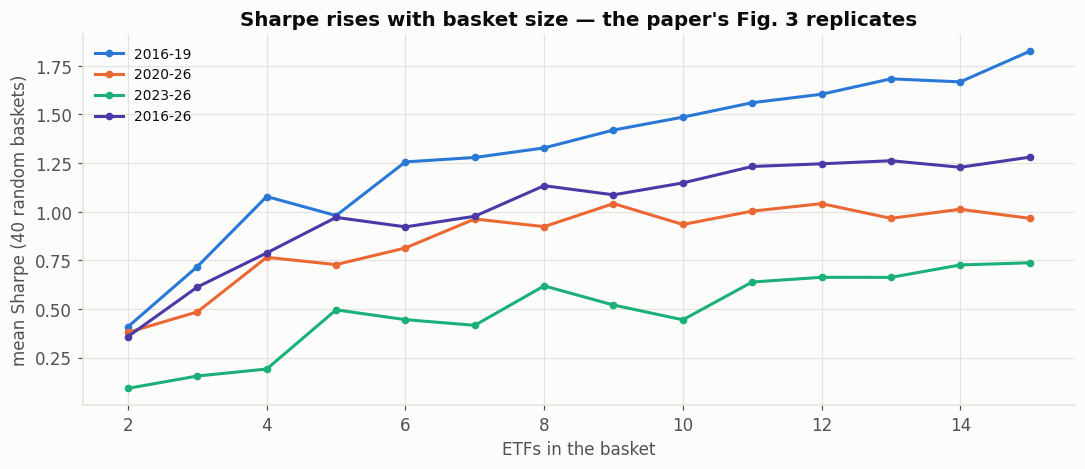

window,overlap 2016-2019,out-of-sample 2020-2026,post-publication 2023-06+,full 2016-2026
kind,,,,
developed,2.39,1.31,0.81,1.63
emerging,0.65,0.63,0.03,0.64
all-15 (mixed),1.70,0.97,0.67,1.22


In [10]:
bk = pd.read_parquet(OUT / "baskets.parquet")
rnd = bk[bk.kind == "random"]
fig, ax = plt.subplots(figsize=(10, 4.4))
for w, c in zip(WINDOWS, ["blue", "orange", "aqua", "violet"]):
    g = rnd[rnd.window == w].groupby("size").sharpe.mean()
    ax.plot(g.index, g, marker="o", ms=4, color=SERIES[c], label=SHORT[w].split("\n")[0], zorder=3)
ax.set_xlabel("ETFs in the basket"); ax.set_ylabel("mean Sharpe (40 random baskets)")
ax.set_title("Sharpe rises with basket size — the paper's Fig. 3 replicates")
ax.legend(fontsize=9); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

ed = bk[bk.kind != "random"].pivot(index="kind", columns="window", values="sharpe")[WINDOWS]
head = pd.read_parquet(OUT / "headline.parquet")
ed.loc["all-15 (mixed)"] = head[head.strategy.str.startswith("MinMax")].set_index("window").sharpe[WINDOWS]
display(ed.style.format("{:.2f}"))

**Basket size replicates.** Mean Sharpe climbs monotonically with the number of ETFs, in
every window. The paper's reasoning is right: a bigger cross-section makes it likelier
that the day's minimum IBS is genuinely near 0 and the maximum genuinely near 1.

**Emerging vs developed does not replicate.** The paper reports emerging baskets having
higher mean and median Sharpe. We find the opposite, decisively and in every window —
developed 2.39 / 1.31 / 0.81 / 1.63 against emerging 0.65 / 0.63 / 0.03 / 0.64. Developed
also beats the mixed all-15 basket, contradicting the paper's Table 7/8 conclusion that
mixed baskets are best.

Two honest caveats: the comparison is not identical (the paper compares distributions
over random sub-baskets; this compares the full emerging group against the full developed
group), and emerging markets had a very different 2016–2026 than 2009–2019. But the sign
is stable across all four windows, which is hard to dismiss.

## 9 — Borrow costs (paper Table 6)

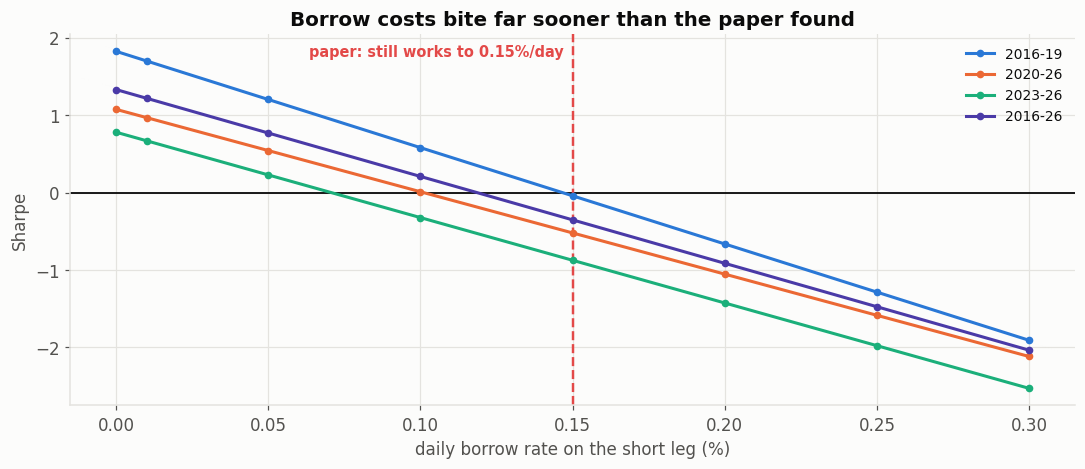

window,overlap 2016-2019,out-of-sample 2020-2026,post-publication 2023-06+,full 2016-2026
daily_rate,,,,
0.000000,1.82,1.07,0.78,1.33
0.000100,1.70,0.97,0.67,1.22
0.000500,1.20,0.54,0.23,0.77
0.001000,0.58,0.01,-0.32,0.21
0.001500,-0.04,-0.52,-0.88,-0.35
0.002000,-0.66,-1.05,-1.43,-0.91
0.002500,-1.29,-1.59,-1.98,-1.48
0.003000,-1.91,-2.12,-2.53,-2.04


In [11]:
b = pd.read_parquet(OUT / "borrow.parquet")
fig, ax = plt.subplots(figsize=(10, 4.4))
for w, c in zip(WINDOWS, ["blue", "orange", "aqua", "violet"]):
    g = b[b.window == w].set_index("daily_rate")
    ax.plot(g.index * 100, g.sharpe_long_short, marker="o", ms=4,
            color=SERIES[c], label=SHORT[w].split("\n")[0], zorder=3)
ax.axhline(0, color=INK, lw=1.2)
ax.axvline(0.15, color=SERIES["red"], lw=1.6, ls="--")
ax.annotate("paper: still works to 0.15%/day", xy=(0.15, ax.get_ylim()[1]),
            xytext=(-6, -14), textcoords="offset points", ha="right",
            color=SERIES["red"], fontsize=9.5, fontweight="bold")
ax.set_xlabel("daily borrow rate on the short leg (%)"); ax.set_ylabel("Sharpe")
ax.set_title("Borrow costs bite far sooner than the paper found")
ax.legend(fontsize=9); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
display(b.pivot(index="daily_rate", columns="window",
                values="sharpe_long_short")[WINDOWS].style.format("{:.2f}"))

**Does not replicate.** The paper reports the strategy surviving to ~0.15%/day
(≈55% annualised). Here it crosses zero at roughly **0.10–0.15% on the paper's own
window** and at **~0.10%** out-of-sample — and post-publication it is already negative at
0.10%.

The reason is the same one as everywhere else in this notebook: the paper's short leg
carried positive expectancy that had to be eaten away before the strategy died. Ours
starts near zero, so any borrow cost at all pushes it under. **Long-only pays no borrow
and is unaffected**, which is another argument for dropping the short leg entirely.

---

# Assumptions

Each with the direction it biases the result.

| # | Assumption | Bias |
|---|---|---|
| 1 | **Window is 2016-2026, not 2009-2019.** Alpaca equity history starts 2016-01-04, removing 7 of the paper's 11 years. | **Understates** the paper-window comparison. 2009–2012 was an exceptionally strong mean-reversion regime; excluding it should lower Sharpe on its own, independent of any decay. |
| 2 | **Trades execute exactly at the closing print.** | **Overstates**, and materially — §6 shows the entire edge lives in the close→open gap. Any delay past the close eats it. |
| 3 | **No commission.** The paper also assumes none (IBKR is $0 under 300k shares). | Small at this trade count for a retail account. |
| 4 | **Borrow is a flat daily rate** on the short leg, as the paper assumes. Real borrow varies by ETF and by day. | Unknown direction; swept explicitly in §9. |
| 5 | **No slippage** in the base case. | **Overstates.** The engine supports a per-side bps charge; it is zero here to match the paper. |
| 6 | **Dividend- and split-adjusted prices** (`adjustment="all"`). IBS is invariant to this (a common factor cancels in the ratio) but returns are not. | Correct for total return; the paper's Yahoo source is ambiguous on this point. |
| 7 | **Sharpe uses rf = 0**, matching the paper. | **Overstates** for 2023–2026, when cash paid ~5%. A cash-adjusted Sharpe for the post-publication window would be lower still. |
| 8 | **EWI is treated as Italy**, per what the paper computed; its Table 1 mislabels it South Korea. | None — it matches the paper's actual data. |
| 9 | **PIN is dropped after 2026-02-20** (fund liquidated); ETFs are simply excluded from days where they have no bar. | Negligible; 1 of 15 names near the end. |
| 10 | **Zero-range bars give NaN IBS** and are excluded rather than treated as 0.5. | Correct; prevents inventing a neutral signal. |
| 11 | **Equal weight within each leg, dollar-neutral, 100% gross.** Sharpe is leverage-invariant so this does not affect the headline. | None on Sharpe; the equity curve scales with the choice. |
| 12 | **Random baskets use 40 draws per size** with a fixed seed. | Sampling noise on the basket-size curve; the trend is stable across all four windows. |

---

# Pros and cons

### Pros

- **The core effect is real and still alive.** The long leg's P(up | IBS < 0.2) is 0.565
  post-publication — identical to the paper's 2009–2019 mean. Ten years and a publication
  later, that is a genuinely durable anomaly.
- **Trivial to compute.** One indicator, daily bars, 15 liquid ETFs. No intraday data, no
  universe construction, no survivorship problem.
- **Low drawdown and low correlation.** 11% volatility with an 11.4% max drawdown on the
  paper window, against IVV's 19.4%.
- **Always invested** — no cash drag, and the 100% time-in is what makes it beat the
  threshold version.
- **Long-only works and needs no borrow, no margin, no shorting approval.** That version
  is directly runnable in an ordinary cash account.
- **Robust variants replicate**: basket size, IBS lookback, holding period, and Min-Max
  beating thresholds all hold.

### Cons

- **The headline does not replicate.** 1.70 on the paper's own window against 2.908, and
  0.67 post-publication.
- **The short leg is broken.** Below a coin flip in every window; short-only Sharpe is
  −0.43 post-publication. Half the paper's strategy is not merely weaker, it is negative.
- **Post-publication it loses to buying IVV** (0.67 vs 1.35) while being far more work.
- **The entire edge is in the closing print.** Open-to-open is ≈0. You must transact
  within seconds of the close, every day, or there is nothing.
- **Borrow costs kill it much sooner than the paper claims** — negative by ~0.10%/day.
- **Daily turnover of the whole book**, 252 days a year, for a thin edge.
- **Emerging/developed conclusion inverts**, which suggests the paper's basket-level
  findings were period-specific rather than structural.
- **No risk control at all.** No stop, no position limit, no regime filter. A gap against
  a concentrated 1-long/1-short book is unhedged.

---

# What running this live would require

**Nothing here may price a live order.** The backtest lane (Alpaca) and the execution
lane (Robinhood MCP) do not touch — see `.claude/skills/data-routing/SKILL.md` and
`execution/PROTOCOL.md`. **No order is placed without explicit human confirmation.**

The operational spec, sized to the actual account, is in
[`executable/ibs_country_etf.md`](executable/ibs_country_etf.md).

### Data
- Daily OHLC for 15 ETFs — trivial, and already cached here.
- **A live price feed in the final minutes of the session.** IBS needs the day's high,
  low and a close estimate *before* the close, so the signal must be computed at ~15:58
  from live data and acted on immediately.

### Execution
- **Market-on-close (MOC) orders** are the correct instrument. Robinhood does not offer
  MOC; the nearest approximation is a market order in the last seconds, which is exactly
  the slippage §6 shows the strategy cannot absorb.
- Long-only removes the need for margin, shorting approval and borrow — and on this data
  it is the *better* strategy, so the constraint costs nothing.
- 2–6 positions a day depending on N, fully turned over daily.

### Capital
- No leverage required (Sharpe is leverage-invariant; 100% gross is fine).
- Whole-share quantization on ~$1k or less would distort a 15-ETF book badly; a few
  thousand dollars is the realistic floor.

### Before risking money
1. **Measure the close-execution gap.** Log the price you actually get versus the
   official close, daily, for a quarter. That single number decides the strategy.
2. **Run long-only.** The short leg is negative on this data and costs borrow.
3. **Re-check the decay** annually — the trend across these three windows is downward.